# Lab 3: Noise Modeling and Modulation Foundations

In this lab, you will explore the characteristics of channel noise using your SDRs and build a fundamental understanding of how digital modulation schemes behave when subjected to that noise.

## Task 1: Modeling of Gaussian Noise

We will capture the noise from the channel by transmitting constant, known symbols and observing how they are scattered upon reception. You will reuse the coarse frequency correction from Lab 2 to lock onto the signal before isolating the noise.

In [44]:
# Done in Lab 1 and 2
import numpy as np
import matplotlib.pyplot as plt
import adi
import time

# --- Hardware Setup ---
fs = int(2.0e6)      # Sample rate: 2.0 MHz[cite: 1]
fc = int(823e6)      # Carrier frequency
tx_scale = 2**14     # DAC full-scale headroom[cite: 1]

# Connect to SDRs
tx_sdr = adi.Pluto("ip:192.168.3.1") 
#[cite: 1]
rx_sdr = adi.Pluto("ip:192.168.2.1") #[cite: 1]

tx_sdr.sample_rate = fs
tx_sdr.tx_lo = fc
tx_sdr.tx_rf_bandwidth = fs
tx_sdr.tx_hardwaregain_chan0 = -10


rx_sdr.sample_rate = fs
rx_sdr.rx_lo = fc
rx_sdr.rx_rf_bandwidth = fs
rx_sdr.gain_control_mode_chan0 = "manual"
rx_sdr.rx_hardwaregain_chan0 = 30
rx_sdr.rx_buffer_size = 20000


# --- Transmit 1,1,1,1... (1D fixed points) ---
tx_symbols_1d = np.ones(10000, dtype=np.complex64) * tx_scale
tx_sdr.tx_cyclic_buffer = True #[cite: 1]
tx_sdr.tx(tx_symbols_1d)
time.sleep(0.5)


# Receive
rx_samples_1d = rx_sdr.rx()
tx_sdr.tx_destroy_buffer()
print(rx_samples_1d[30:100])

[387.-208.j 389.-206.j 390.-204.j 391.-201.j 392.-199.j 392.-201.j
 394.-199.j 394.-195.j 395.-193.j 396.-190.j 397.-188.j 398.-185.j
 401.-186.j 400.-183.j 401.-179.j 403.-177.j 404.-176.j 405.-173.j
 406.-171.j 406.-170.j 407.-169.j 410.-164.j 410.-161.j 411.-160.j
 408.-158.j 411.-156.j 411.-152.j 414.-152.j 413.-150.j 415.-145.j
 417.-143.j 416.-143.j 418.-141.j 419.-136.j 419.-136.j 420.-134.j
 423.-132.j 421.-130.j 422.-128.j 423.-124.j 424.-121.j 424.-120.j
 425.-119.j 425.-116.j 426.-113.j 427.-113.j 428.-106.j 429.-106.j
 431.-102.j 430.-100.j 430. -98.j 430. -96.j 432. -94.j 432. -91.j
 431. -89.j 432. -87.j 433. -83.j 433. -83.j 435. -81.j 434. -77.j
 433. -78.j 435. -74.j 435. -71.j 435. -69.j 435. -65.j 437. -64.j
 437. -60.j 437. -59.j 438. -55.j 439. -55.j]


## Task 1: Modeling 1D Gaussian Noise

Transmit a constant stream of maximum-amplitude real symbols (DC).

**Instructions & Questions:**
1. **Intermediate Plot:** Plot the first 200 raw time-domain samples (Real and Imaginary). Observe the y-axis: is the signal centered at zero? Why or why not?
2. Strip the DC offset from the received samples.
3. Apply coarse frequency synchronization (using phase differentials)(done in Lab 2) .
4. **Final Plot:** Subtract the mean signal estimate to isolate the channel noise. Plot a 60-bin histogram of the real component of the noise.

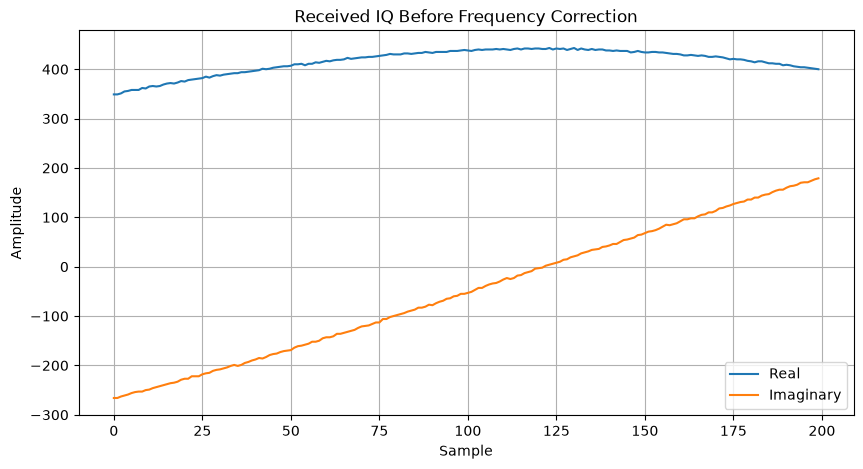

Initial received signal phase: -37.31383965112869 degrees


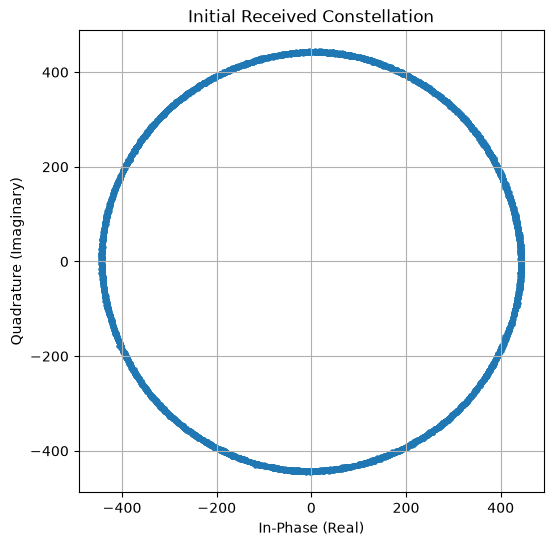

Estimated phase difference: 0.005297516811822175 radians
Estimated frequency offset in degrees/sample: 0.30352535521701013


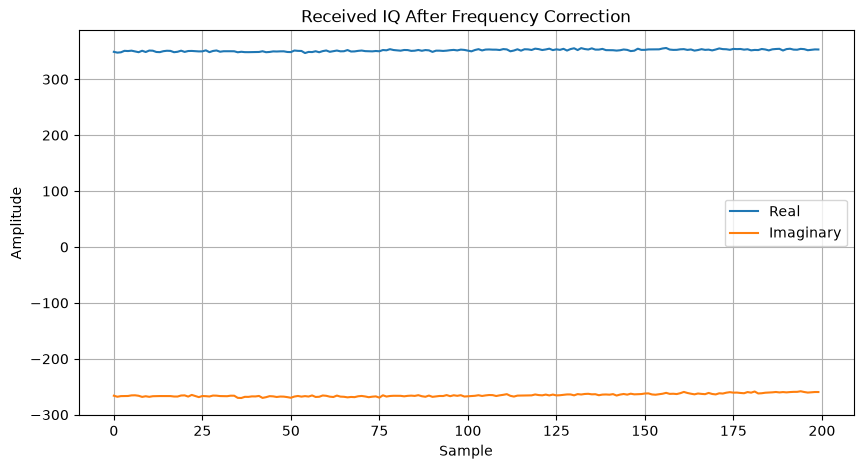

Phase after frequency correction: -37.02809550517561 degrees
Phase correction required: 37.02809550517561 degrees
Final received signal phase: 6.019418199151608e-15 degrees


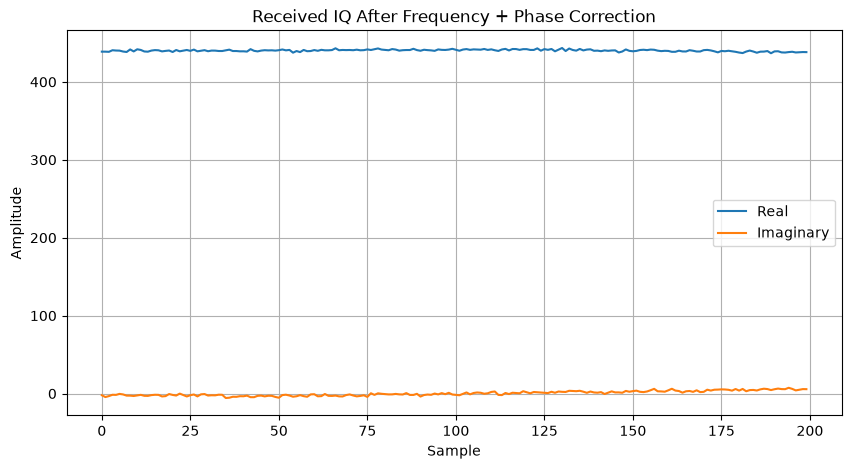

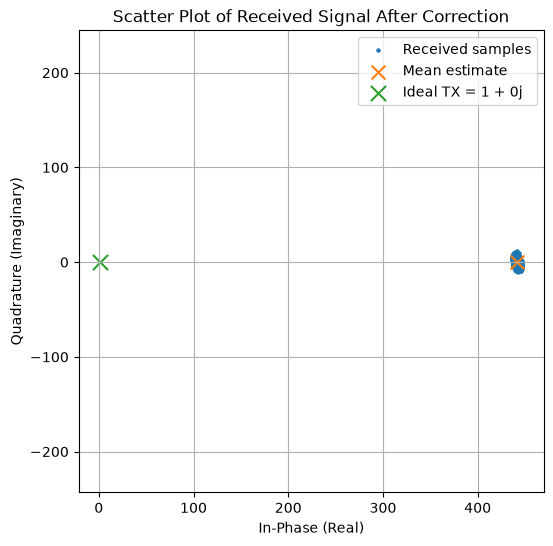

Estimated DC component: (441.5078858170351+4.6384229790419343e-14j)
Estimated DC magnitude: 441.5078858170351
Estimated DC phase: 6.019418199151608e-15 degrees
Mean of isolated noise: (5.911715561524034e-15+9.094947017729283e-17j)


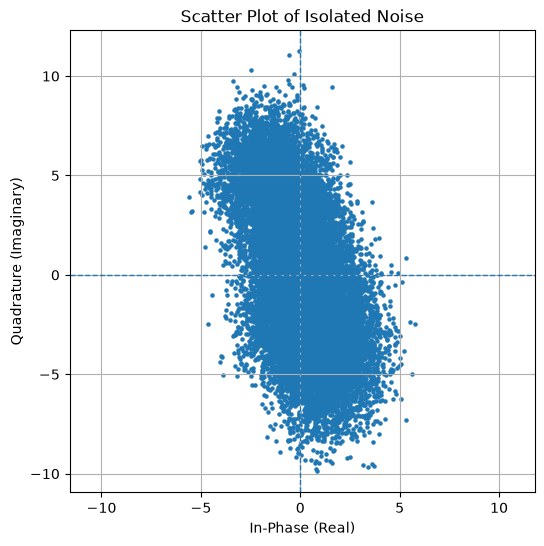

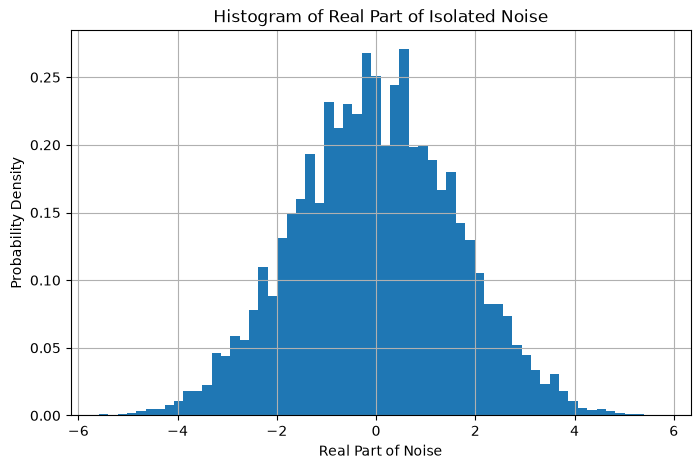

Noise variance: 16.355661371871044


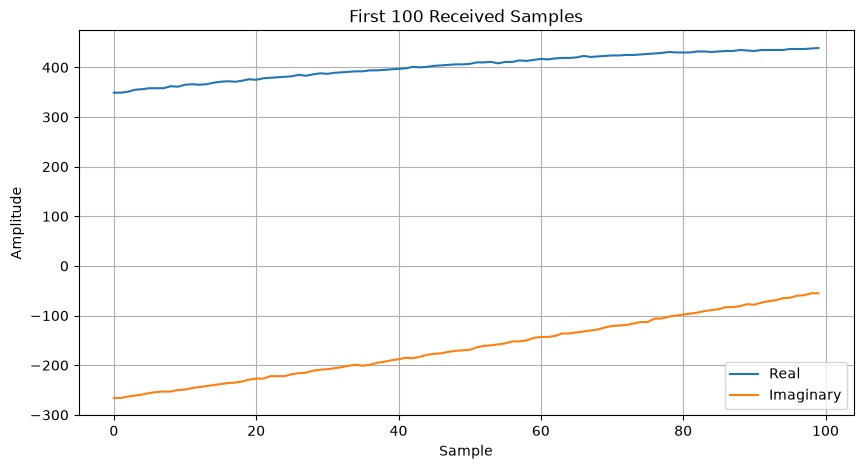

In [45]:
###################################################################
# TODO: Coarse Frequency Correction & 1D Noise Histogram
###################################################################

# 1. Place the coarse frequency correction you implemented in Lab 2 over here. Plot the received IQ before and after correction
#    (conjugate multiplication and estimation).

# Plot the received IQ before correction
plt.figure(figsize=(10, 5))
plt.plot(np.real(rx_samples_1d[:200]), label="Real")
plt.plot(np.imag(rx_samples_1d[:200]), label="Imaginary")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.title("Received IQ Before Frequency Correction")
plt.legend()
plt.grid()
plt.show()


# ---------------------------------------------------------------
# Initial phase of the received signal
# ---------------------------------------------------------------

# Since frequency offset causes the signal phase to rotate with
# sample number, the first sample represents the initial phase.

initial_phase = np.angle(
    rx_samples_1d[0],
    deg=True
)

print(
    "Initial received signal phase:",
    initial_phase,
    "degrees"
)


# ---------------------------------------------------------------
# Plot initial received constellation
# ---------------------------------------------------------------

plt.figure(figsize=(6, 6))

plt.scatter(
    np.real(rx_samples_1d),
    np.imag(rx_samples_1d),
    s=5
)

plt.xlabel("In-Phase (Real)")
plt.ylabel("Quadrature (Imaginary)")
plt.title("Initial Received Constellation")
plt.grid()
plt.axis("equal")
plt.show()


# --- Remove DC offset ---

# For Task 1, the transmitter is sending:
#
# TX = 1 + 0j
#
# Therefore, we do NOT subtract the mean here.
# The mean contains the transmitted signal itself.
#
# We use the original received samples for frequency correction.

rx_dc_corrected = rx_samples_1d


# --- Coarse frequency correction using phase differentials ---

# Conjugate multiplication of consecutive samples
phase_diff = (
    rx_dc_corrected[1:]
    * np.conj(rx_dc_corrected[:-1])
)


# Estimate the average phase difference
estimated_phase = np.angle(
    np.mean(phase_diff)
)


print(
    "Estimated phase difference:",
    estimated_phase,
    "radians"
)

print(
    "Estimated frequency offset in degrees/sample:",
    np.degrees(estimated_phase)
)


# Generate sample index
n = np.arange(
    len(rx_dc_corrected)
)


# Generate frequency correction signal
correction = np.exp(
    -1j * estimated_phase * n
)


# Apply frequency correction
rx_frequency_corrected = (
    rx_dc_corrected * correction
)


# Plot the received IQ after frequency correction
plt.figure(figsize=(10, 5))

plt.plot(
    np.real(rx_frequency_corrected[:200]),
    label="Real"
)

plt.plot(
    np.imag(rx_frequency_corrected[:200]),
    label="Imaginary"
)

plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.title("Received IQ After Frequency Correction")
plt.legend()
plt.grid()
plt.show()


# ---------------------------------------------------------------
# Estimate phase after frequency correction
# ---------------------------------------------------------------

phase_corrected_signal_estimate = np.mean(
    rx_frequency_corrected
)

phase_after_frequency_correction = np.angle(
    phase_corrected_signal_estimate,
    deg=True
)

print(
    "Phase after frequency correction:",
    phase_after_frequency_correction,
    "degrees"
)


# ---------------------------------------------------------------
# Phase correction
#
# Target phase = 0 degrees
# ---------------------------------------------------------------

target_phase = 0.0

phase_error = (
    target_phase
    - phase_after_frequency_correction
)

print(
    "Phase correction required:",
    phase_error,
    "degrees"
)


# Convert phase correction from degrees to radians
phase_correction = np.exp(
    1j * np.radians(phase_error)
)


# Apply phase correction
rx_corrected = (
    rx_frequency_corrected
    * phase_correction
)


# ---------------------------------------------------------------
# Calculate final phase
# ---------------------------------------------------------------

final_signal_estimate = np.mean(
    rx_corrected
)

final_phase = np.angle(
    final_signal_estimate,
    deg=True
)

print(
    "Final received signal phase:",
    final_phase,
    "degrees"
)


# ---------------------------------------------------------------
# Plot the received IQ after frequency and phase correction
# ---------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    np.real(rx_corrected[:200]),
    label="Real"
)

plt.plot(
    np.imag(rx_corrected[:200]),
    label="Imaginary"
)

plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.title("Received IQ After Frequency + Phase Correction")
plt.legend()
plt.grid()
plt.show()


# ---------------------------------------------------------------
# Scatter plot of received signal
# ---------------------------------------------------------------

plt.figure(figsize=(6, 6))

plt.scatter(
    np.real(rx_corrected),
    np.imag(rx_corrected),
    s=5,
    label="Received samples"
)


# Plot the estimated received signal
plt.scatter(
    np.real(final_signal_estimate),
    np.imag(final_signal_estimate),
    s=100,
    marker="x",
    label="Mean estimate"
)


# Plot ideal transmitted signal
plt.scatter(
    1,
    0,
    s=120,
    marker="x",
    label="Ideal TX = 1 + 0j"
)


plt.xlabel("In-Phase (Real)")
plt.ylabel("Quadrature (Imaginary)")
plt.title("Scatter Plot of Received Signal After Correction")
plt.legend()
plt.grid()
plt.axis("equal")
plt.show()


# 2. Write the code for subtracting the expected received signal (the '1's)
#    from your corrected samples to isolate the noise.

# The transmitter is sending:
#
# TX = 1 + 0j
#
# Therefore, after frequency and phase correction,
# the received signal contains:
#
# RX = DC signal + noise
#
# The DC component represents the received version of
# the transmitted constant signal.
#
# We estimate this DC component and subtract it
# to isolate the noise.


# ---------------------------------------------------------------
# Estimate DC component
# ---------------------------------------------------------------

dc_component = np.mean(
    rx_corrected
)

print(
    "Estimated DC component:",
    dc_component
)

print(
    "Estimated DC magnitude:",
    np.abs(dc_component)
)

print(
    "Estimated DC phase:",
    np.angle(
        dc_component,
        deg=True
    ),
    "degrees"
)


# ---------------------------------------------------------------
# Remove DC component to isolate noise
# ---------------------------------------------------------------

noise_1d = (
    rx_corrected
    - dc_component
)


# ---------------------------------------------------------------
# Check mean of isolated noise
# ---------------------------------------------------------------

noise_mean = np.mean(
    noise_1d
)

print(
    "Mean of isolated noise:",
    noise_mean
)


# ---------------------------------------------------------------
# Scatter plot of isolated noise
# ---------------------------------------------------------------

plt.figure(figsize=(6, 6))

plt.scatter(
    np.real(noise_1d),
    np.imag(noise_1d),
    s=5
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("In-Phase (Real)")
plt.ylabel("Quadrature (Imaginary)")
plt.title("Scatter Plot of Isolated Noise")
plt.grid()
plt.axis("equal")
plt.show()


# 3. Plot the histogram of the real part of the isolated noise along the x-axis.
#    It should resemble a Gaussian (normal) distribution.

plt.figure(figsize=(8, 5))

plt.hist(
    np.real(noise_1d),
    bins=60,
    density=True
)

plt.xlabel("Real Part of Noise")
plt.ylabel("Probability Density")
plt.title("Histogram of Real Part of Isolated Noise")
plt.grid()
plt.show()


# --- VISUALIZATION & INSIGHT TIPS ---
# TIP: Print the variance (np.var) of your isolated noise. Does the number seem reasonable?

print(
    "Noise variance:",
    np.var(noise_1d)
)


# TIP: Plot the first 100 samples of the received signal against time (plt.plot).
#      You should visually see the noise "riding" on top of the constant DC level.

plt.figure(figsize=(10, 5))

plt.plot(
    np.real(rx_samples_1d[:100]),
    label="Real"
)

plt.plot(
    np.imag(rx_samples_1d[:100]),
    label="Imaginary"
)

plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.title("First 100 Received Samples")
plt.legend()
plt.grid()
plt.show()

> **Stop and Ponder:** Think about the frequency correction step you just performed. Why is it absolutely crucial to correct the frequency offset *before* attempting to isolate and plot the noise? What would your histogram look like if the frequency offset was still present?

### Complex Noise (2D)
Now we will repeat the experiment but transmit $1+1j$ to observe noise in the complex plane.
Transmit the complex symbol `1 + 1j` scaled appropriately.

**Instructions & Questions:**
1. Strip the DC offset and perform coarse frequency correction.
2. **Intermediate Plot:** Before subtracting the signal mean, plot the locked complex constellation scatter plot. Overlay the mean estimate as a prominent red marker.
3. **Final Plot:** Subtract the mean to center the cluster at (0,0) and generate a 2D histogram (heatmap) of the complex noise.

In [38]:
# --- Transmit 1+1j (Complex fixed points) ---
tx_symbols_2d = (np.ones(10000) + 1j*np.ones(10000)).astype(np.complex64) * (tx_scale / np.sqrt(2))
tx_sdr.tx_cyclic_buffer = True #[cite: 1]
tx_sdr.tx(tx_symbols_2d)
time.sleep(0.5)

# Receive
rx_samples_2d = rx_sdr.rx()
tx_sdr.tx_destroy_buffer()
print(rx_samples_2d[50:80])

[319.-280.j 321.-279.j 323.-278.j 325.-275.j 325.-274.j 326.-270.j
 329.-270.j 332.-268.j 331.-266.j 331.-263.j 335.-263.j 337.-261.j
 337.-258.j 338.-255.j 341.-254.j 341.-253.j 344.-251.j 345.-249.j
 344.-247.j 347.-245.j 347.-242.j 350.-242.j 351.-237.j 353.-237.j
 351.-235.j 352.-234.j 355.-233.j 357.-230.j 358.-227.j 360.-223.j]


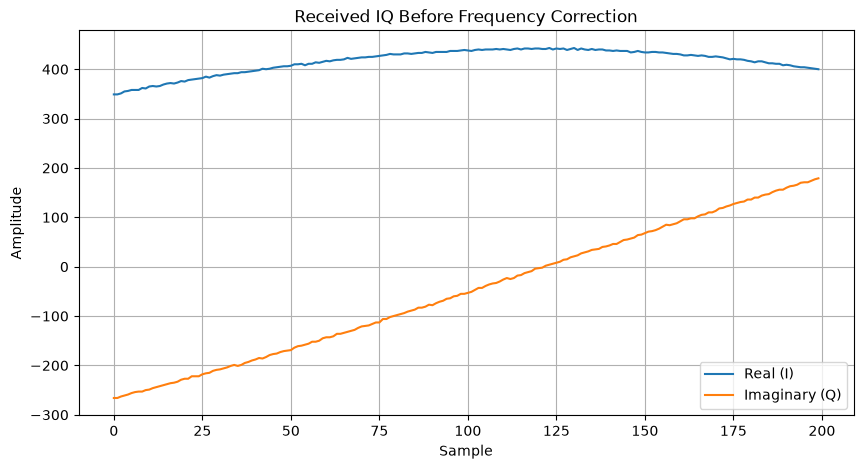

Initial received signal phase: 119.02018354835128 degrees


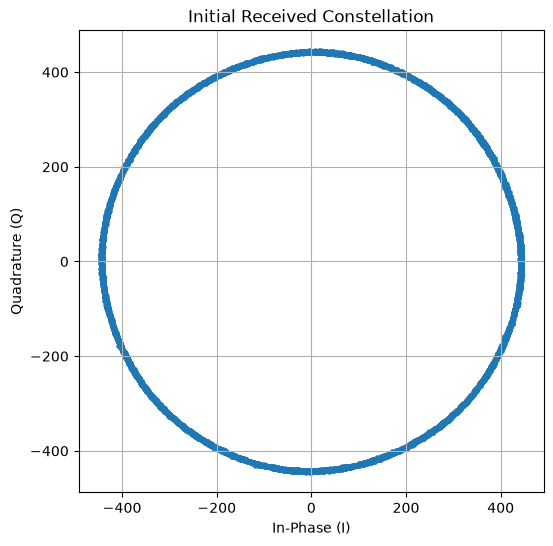

Estimated phase difference: 0.005297533162530923
Estimated frequency offset: 0.3035262920436135 degrees/sample


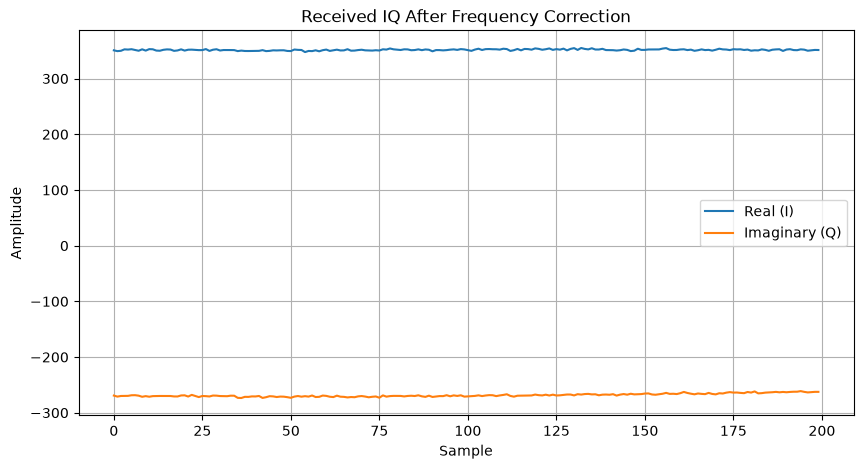

Phase after frequency correction: -37.03753444402574 degrees
Phase correction required: 82.03753444402574 degrees
Final received signal phase: 45.000000000000014 degrees


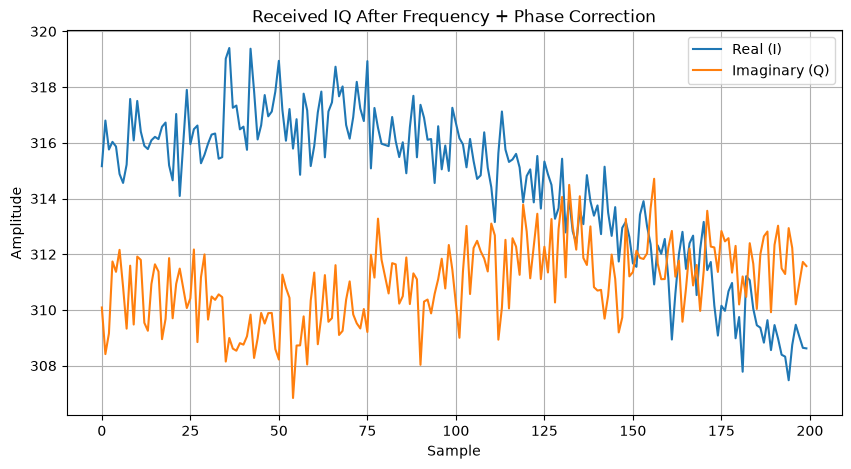

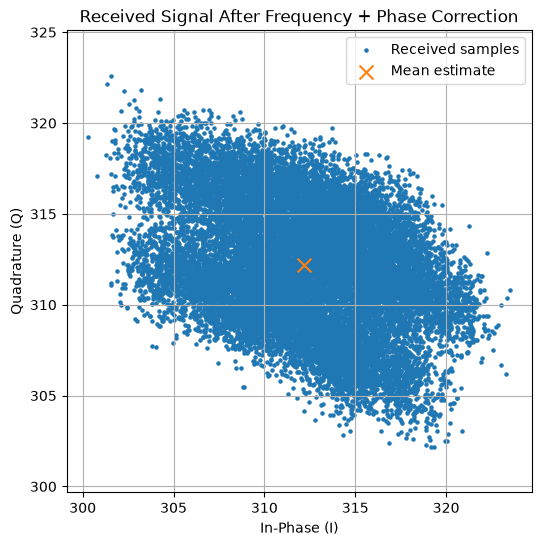


Estimated received signal: (312.172916213323+312.1729162133231j)


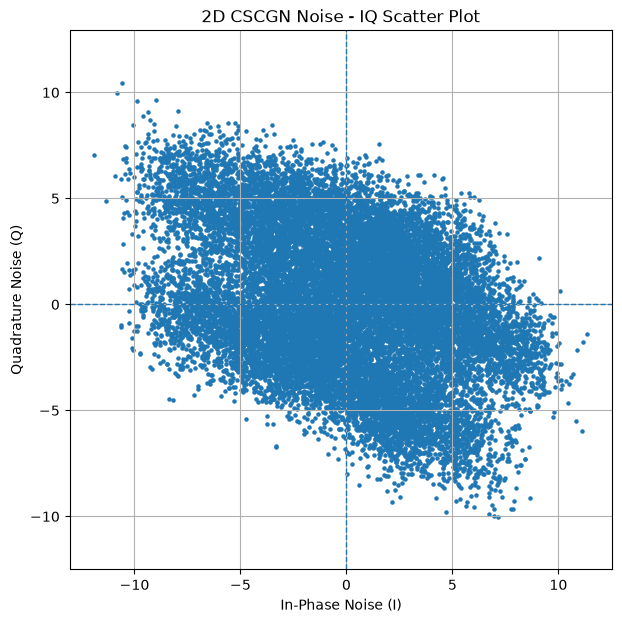


          2D CSCGN NOISE STATISTICS
Mean I: 6.730260793119669e-15
Mean Q: -4.42355485574808e-14
Variance I: 17.169267078662873
Variance Q: 11.42444544053467
Complex noise variance: 28.593712519197545


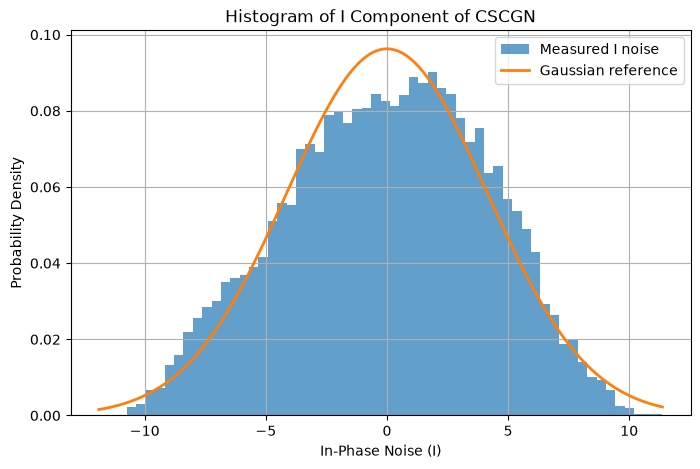

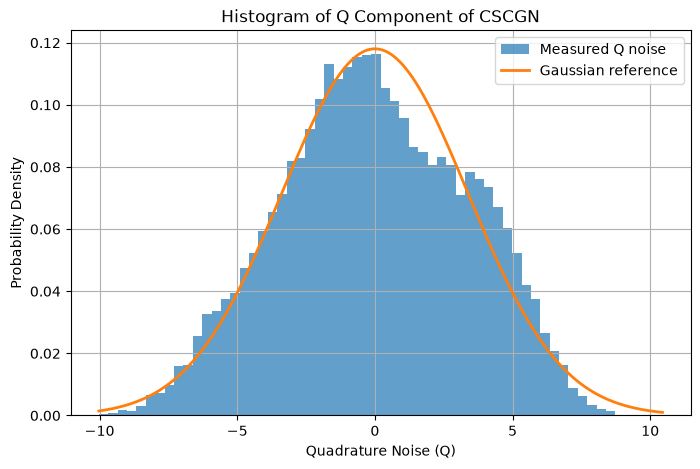

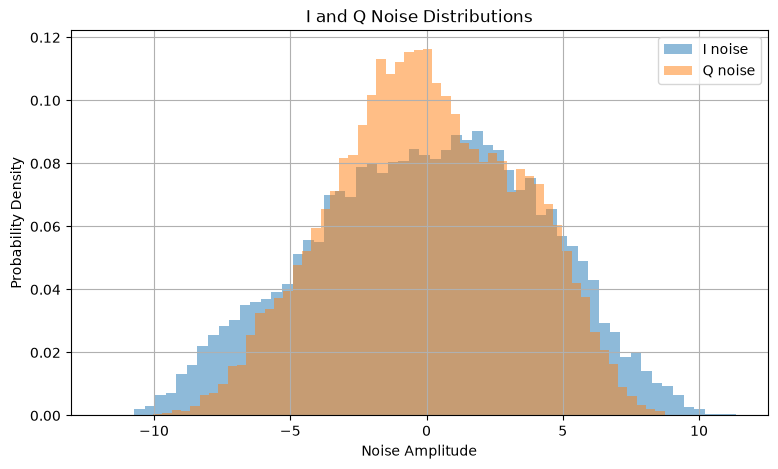


             FINAL NOISE SUMMARY
I mean       : 6.730260793119669e-15
Q mean       : -4.42355485574808e-14
I variance   : 17.169267078662873
Q variance   : 11.42444544053467
I std        : 4.1435814314024135
Q std        : 3.3800067219659002
Complex var  : 28.593712519197545


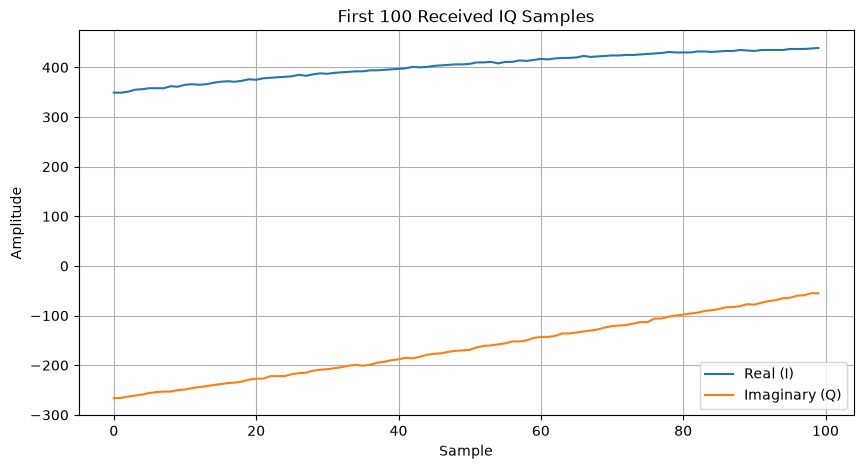

In [111]:
###################################################################
# TASK: Coarse Frequency Correction & 2D CSCGN Noise Analysis
###################################################################

import numpy as np
import matplotlib.pyplot as plt


# ===============================================================
# 1. RECEIVED IQ BEFORE FREQUENCY CORRECTION
# ===============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    np.real(rx_samples_1d[:200]),
    label="Real (I)"
)

plt.plot(
    np.imag(rx_samples_1d[:200]),
    label="Imaginary (Q)"
)

plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.title("Received IQ Before Frequency Correction")

plt.legend()
plt.grid()

plt.show()


# ===============================================================
# 2. INITIAL PHASE
# ===============================================================

initial_signal_estimate = np.mean(
    rx_samples_1d
)

initial_phase = np.angle(
    initial_signal_estimate,
    deg=True
)

print(
    "Initial received signal phase:",
    initial_phase,
    "degrees"
)


# ===============================================================
# 3. INITIAL CONSTELLATION
# ===============================================================

plt.figure(figsize=(6, 6))

plt.scatter(
    np.real(rx_samples_1d),
    np.imag(rx_samples_1d),
    s=5
)

plt.xlabel("In-Phase (I)")
plt.ylabel("Quadrature (Q)")

plt.title(
    "Initial Received Constellation"
)

plt.grid()
plt.axis("equal")

plt.show()


# ===============================================================
# 4. REMOVE DC OFFSET
# ===============================================================

rx_dc_corrected = (
    rx_samples_1d -
    np.mean(rx_samples_1d)
)


# ===============================================================
# 5. COARSE FREQUENCY ESTIMATION
# ===============================================================

# Consecutive-sample conjugate multiplication:
#
# r[n] * conj(r[n-1])
#
# The angle gives the phase change between samples.

phase_diff = (
    rx_dc_corrected[1:] *
    np.conj(rx_dc_corrected[:-1])
)


# Average phase difference

estimated_phase = np.angle(
    np.mean(phase_diff)
)


print(
    "Estimated phase difference:",
    estimated_phase
)

print(
    "Estimated frequency offset:",
    np.degrees(estimated_phase),
    "degrees/sample"
)


# ===============================================================
# 6. FREQUENCY CORRECTION
# ===============================================================

n = np.arange(
    len(rx_dc_corrected)
)


correction = np.exp(
    -1j *
    estimated_phase *
    n
)


rx_frequency_corrected = (
    rx_dc_corrected *
    correction
)


# ===============================================================
# 7. RECEIVED IQ AFTER FREQUENCY CORRECTION
# ===============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    np.real(rx_frequency_corrected[:200]),
    label="Real (I)"
)

plt.plot(
    np.imag(rx_frequency_corrected[:200]),
    label="Imaginary (Q)"
)

plt.xlabel("Sample")
plt.ylabel("Amplitude")

plt.title(
    "Received IQ After Frequency Correction"
)

plt.legend()
plt.grid()

plt.show()


# ===============================================================
# 8. PHASE AFTER FREQUENCY CORRECTION
# ===============================================================

phase_corrected_signal_estimate = np.mean(
    rx_frequency_corrected
)


phase_after_frequency_correction = np.angle(
    phase_corrected_signal_estimate,
    deg=True
)


print(
    "Phase after frequency correction:",
    phase_after_frequency_correction,
    "degrees"
)


# ===============================================================
# 9. PHASE CORRECTION
# ===============================================================

# Desired phase

target_phase = 45.0


phase_error = (
    target_phase -
    phase_after_frequency_correction
)


print(
    "Phase correction required:",
    phase_error,
    "degrees"
)


phase_correction = np.exp(
    1j *
    np.radians(phase_error)
)


rx_corrected = (
    rx_frequency_corrected *
    phase_correction
)


# ===============================================================
# 10. FINAL PHASE
# ===============================================================

final_signal_estimate = np.mean(
    rx_corrected
)


final_phase = np.angle(
    final_signal_estimate,
    deg=True
)


print(
    "Final received signal phase:",
    final_phase,
    "degrees"
)


# ===============================================================
# 11. IQ AFTER FREQUENCY + PHASE CORRECTION
# ===============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    np.real(rx_corrected[:200]),
    label="Real (I)"
)

plt.plot(
    np.imag(rx_corrected[:200]),
    label="Imaginary (Q)"
)

plt.xlabel("Sample")
plt.ylabel("Amplitude")

plt.title(
    "Received IQ After Frequency + Phase Correction"
)

plt.legend()
plt.grid()

plt.show()


# ===============================================================
# 12. FINAL CONSTELLATION
# ===============================================================

plt.figure(figsize=(6, 6))

plt.scatter(
    np.real(rx_corrected),
    np.imag(rx_corrected),
    s=5,
    label="Received samples"
)


plt.scatter(
    np.real(final_signal_estimate),
    np.imag(final_signal_estimate),
    s=100,
    marker="x",
    label="Mean estimate"
)


plt.xlabel("In-Phase (I)")
plt.ylabel("Quadrature (Q)")

plt.title(
    "Received Signal After Frequency + Phase Correction"
)

plt.legend()
plt.grid()
plt.axis("equal")

plt.show()


###################################################################
# 2D NOISE EXTRACTION
###################################################################


# ===============================================================
# 13. ESTIMATE RECEIVED SIGNAL
# ===============================================================

signal_estimate = np.mean(
    rx_corrected
)


print()
print(
    "Estimated received signal:",
    signal_estimate
)


# ===============================================================
# 14. ISOLATE 2D COMPLEX NOISE
# ===============================================================

# Received signal:
#
#       r = s + n
#
# Therefore:
#
#       n = r - s
#
# We estimate s using the mean received signal.

noise_2d = (
    rx_corrected -
    signal_estimate
)


###################################################################
# 2D CSCGN VISUALIZATION
###################################################################


# ===============================================================
# 15. 2D IQ SCATTER PLOT OF NOISE
# ===============================================================

plt.figure(figsize=(7, 7))

plt.scatter(
    np.real(noise_2d),
    np.imag(noise_2d),
    s=5
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel(
    "In-Phase Noise (I)"
)

plt.ylabel(
    "Quadrature Noise (Q)"
)

plt.title(
    "2D CSCGN Noise - IQ Scatter Plot"
)

plt.grid()

plt.axis("equal")

plt.show()


# ===============================================================
# 16. SEPARATE I AND Q NOISE
# ===============================================================

noise_I = np.real(
    noise_2d
)

noise_Q = np.imag(
    noise_2d
)


# ===============================================================
# 17. NOISE STATISTICS
# ===============================================================

mean_I = np.mean(
    noise_I
)

mean_Q = np.mean(
    noise_Q
)


variance_I = np.var(
    noise_I
)

variance_Q = np.var(
    noise_Q
)


variance_complex = np.var(
    noise_2d
)


print()
print("==============================================")
print("          2D CSCGN NOISE STATISTICS")
print("==============================================")

print(
    "Mean I:",
    mean_I
)

print(
    "Mean Q:",
    mean_Q
)

print(
    "Variance I:",
    variance_I
)

print(
    "Variance Q:",
    variance_Q
)

print(
    "Complex noise variance:",
    variance_complex
)

print("==============================================")


###################################################################
# HISTOGRAMS
###################################################################


# ===============================================================
# 18. HISTOGRAM OF I NOISE
# ===============================================================

plt.figure(figsize=(8, 5))

count_I, bins_I, _ = plt.hist(
    noise_I,
    bins=60,
    density=True,
    alpha=0.7,
    label="Measured I noise"
)


# Gaussian reference curve

sigma_I = np.std(
    noise_I
)


x_I = np.linspace(
    np.min(noise_I),
    np.max(noise_I),
    500
)


gaussian_I = (
    1 /
    (
        sigma_I *
        np.sqrt(2 * np.pi)
    )
) * np.exp(
    -0.5 *
    (
        (x_I - mean_I) /
        sigma_I
    ) ** 2
)


plt.plot(
    x_I,
    gaussian_I,
    linewidth=2,
    label="Gaussian reference"
)


plt.xlabel(
    "In-Phase Noise (I)"
)

plt.ylabel(
    "Probability Density"
)

plt.title(
    "Histogram of I Component of CSCGN"
)

plt.legend()
plt.grid()

plt.show()


# ===============================================================
# 19. HISTOGRAM OF Q NOISE
# ===============================================================

plt.figure(figsize=(8, 5))

count_Q, bins_Q, _ = plt.hist(
    noise_Q,
    bins=60,
    density=True,
    alpha=0.7,
    label="Measured Q noise"
)


# Gaussian reference curve

sigma_Q = np.std(
    noise_Q
)


x_Q = np.linspace(
    np.min(noise_Q),
    np.max(noise_Q),
    500
)


gaussian_Q = (
    1 /
    (
        sigma_Q *
        np.sqrt(2 * np.pi)
    )
) * np.exp(
    -0.5 *
    (
        (x_Q - mean_Q) /
        sigma_Q
    ) ** 2
)


plt.plot(
    x_Q,
    gaussian_Q,
    linewidth=2,
    label="Gaussian reference"
)


plt.xlabel(
    "Quadrature Noise (Q)"
)

plt.ylabel(
    "Probability Density"
)

plt.title(
    "Histogram of Q Component of CSCGN"
)

plt.legend()
plt.grid()

plt.show()


###################################################################
# OPTIONAL: COMBINED I/Q HISTOGRAM
###################################################################


# ===============================================================
# 20. I AND Q HISTOGRAM TOGETHER
# ===============================================================

plt.figure(figsize=(9, 5))

plt.hist(
    noise_I,
    bins=60,
    density=True,
    alpha=0.5,
    label="I noise"
)

plt.hist(
    noise_Q,
    bins=60,
    density=True,
    alpha=0.5,
    label="Q noise"
)


plt.xlabel(
    "Noise Amplitude"
)

plt.ylabel(
    "Probability Density"
)

plt.title(
    "I and Q Noise Distributions"
)

plt.legend()

plt.grid()

plt.show()


###################################################################
# FINAL SUMMARY
###################################################################


print()
print("==============================================")
print("             FINAL NOISE SUMMARY")
print("==============================================")

print(
    "I mean       :",
    mean_I
)

print(
    "Q mean       :",
    mean_Q
)

print(
    "I variance   :",
    variance_I
)

print(
    "Q variance   :",
    variance_Q
)

print(
    "I std        :",
    sigma_I
)

print(
    "Q std        :",
    sigma_Q
)

print(
    "Complex var  :",
    variance_complex
)

print("==============================================")


###################################################################
# 21. FIRST 100 RECEIVED SAMPLES
###################################################################

plt.figure(figsize=(10, 5))

plt.plot(
    np.real(rx_samples_1d[:100]),
    label="Real (I)"
)

plt.plot(
    np.imag(rx_samples_1d[:100]),
    label="Imaginary (Q)"
)

plt.xlabel("Sample")
plt.ylabel("Amplitude")

plt.title(
    "First 100 Received IQ Samples"
)

plt.legend()
plt.grid()

plt.show()

> **Stop and Ponder:** If your 2D histogram or scatter plot turned out to be strictly elliptical (stretched out along one axis) instead of circular, what physical imperfections in the SDR hardware's I and Q channels might cause this?

## Task 2: Modulation Schemes and Decoding Intuition

*Note: This task is purely Python-based. No SDR hardware is required.*

In this task, we explore the mathematics of how we represent digital information and what happens when the types of noise you isolated in Task 1 corrupt those signals.

### Modulation and Noise
**BPSK (Binary Phase Shift Keying):** Symbols are distributed on a 1D line. The transmitted symbol $s$ is either positive or negative based on the signal energy $E_s$.
$$s \in \{+\sqrt{E_s}, -\sqrt{E_s}\}$$

**4-QAM (Quadrature Amplitude Modulation):** Symbols are distributed in a 2D complex plane.
$$s \in \{\pm \sqrt{E_s/2} \pm j\sqrt{E_s/2}\}$$

**Additive White Gaussian Noise (AWGN):** When a signal travels through a channel, it picks up noise. The received signal $y$ is the transmitted symbol $s$ plus noise $w$:
$$y = s + w$$

For 1D signals (like BPSK), the noise is purely Real Gaussian Noise (GN):
$$w \sim \mathbb{N}(0, \sigma^2)$$

For 2D signals (like 4-QAM), the noise is Complex Standard Circular Gaussian Noise (CSCGN). This is essentially a 2D Gaussian where the real and imaginary parts are independent:
$$w \sim \mathbb{CN}(0, \sigma^2) = \mathbb{N}(0, \sigma^2/2) + j\mathbb{N}(0, \sigma^2/2)$$

### Your Task
Suppose you receive a corrupted symbol $y$. If you know the transmitted symbol was chosen from a specific set of fixed points (like the BPSK or 4-QAM constellations), and the noise acts as a random, symmetric "cloud" or "nudge" in any direction, how would you intuitively decide which symbol was originally sent?

*Hint: Think about the geometry of the situation. If you are standing at point $y$, which constellation point makes the most logical sense to guess based on distance? Mathematically, if your ideal constellation points are $s_i$, you want to find the point that minimizes the Euclidean distance to $y$: $\arg\min_{s_i} |y - s_i|$. This intuitive geometric approach is exactly equivalent to **Maximum Likelihood (ML)** decoding for AWGN channels!*

**Implementation:** (Generate intermediate plots for visualization of each step)
1. Write code to generate arrays of random BPSK and 4-QAM symbols.
2. Add GN to your BPSK symbols and CSCGN to your 4-QAM symbols.
3. Implement your intuitive nearest-neighbor decoding logic to guess the original symbols from the noisy received ones.
4. Calculate the **Symbol Error Rate (SER)** (Number of incorrect guesses / Total symbols).
5. Test how the SER changes with varying **Signal-to-Noise Ratio (SNR)**. Fix your signal power (e.g., $E_s = 1$) and write a loop to sweep through a range of noise variances ($\sigma^2$) or visa-versa(Try both methods). Plot the calculated error rate on the y-axis against the noise variance or SNR on the x-axis to visualize the performance degradation.

> **Stop and Ponder:** As you artificially increase the noise power (making the noise clouds wider and wider), the distinct clusters of points will begin to overlap and merge. At what point does your intuitive geometric decoding logic start to fail? Is it a gradual increase in errors, or a sudden total failure?

BPSK Symbol Error Rate: 0.0006


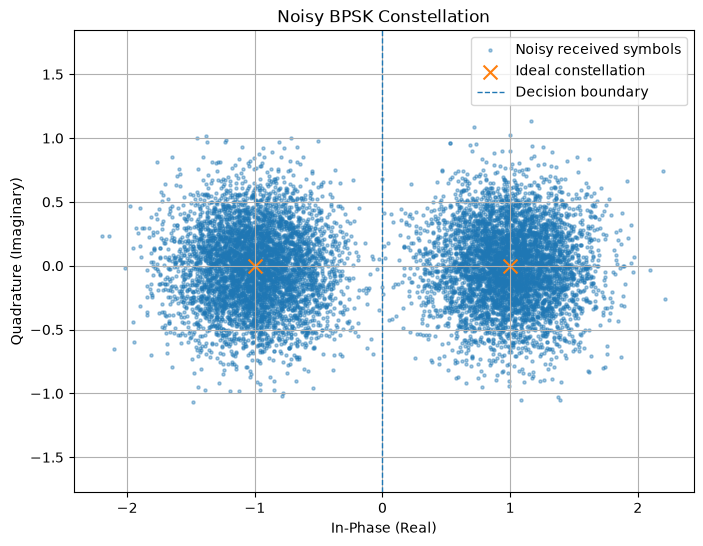

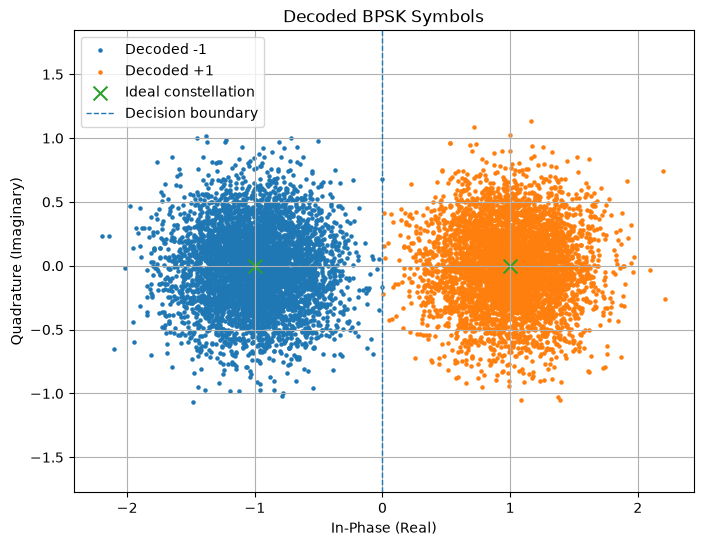

4-QAM Symbol Error Rate: 0.0251


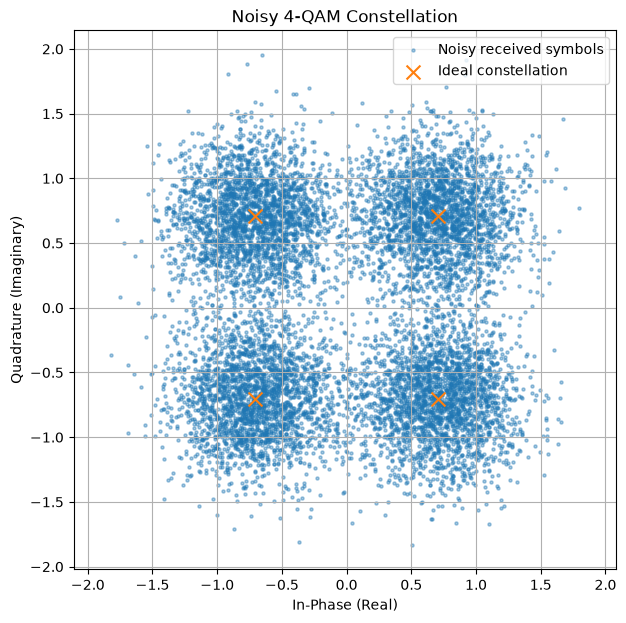

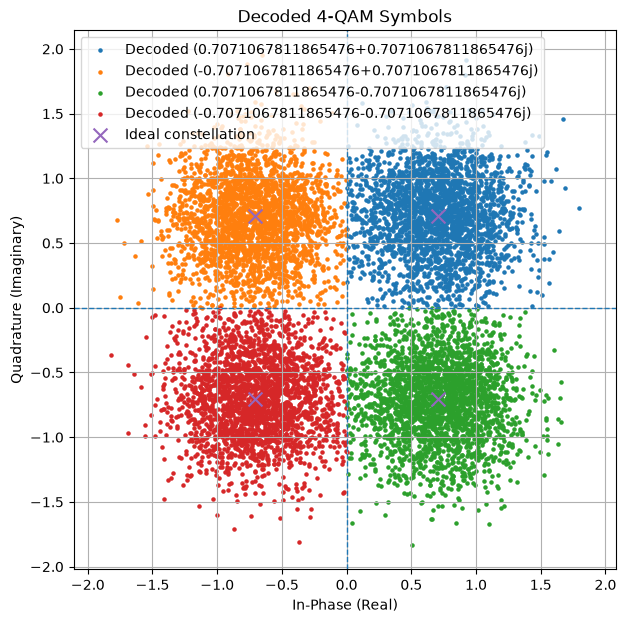

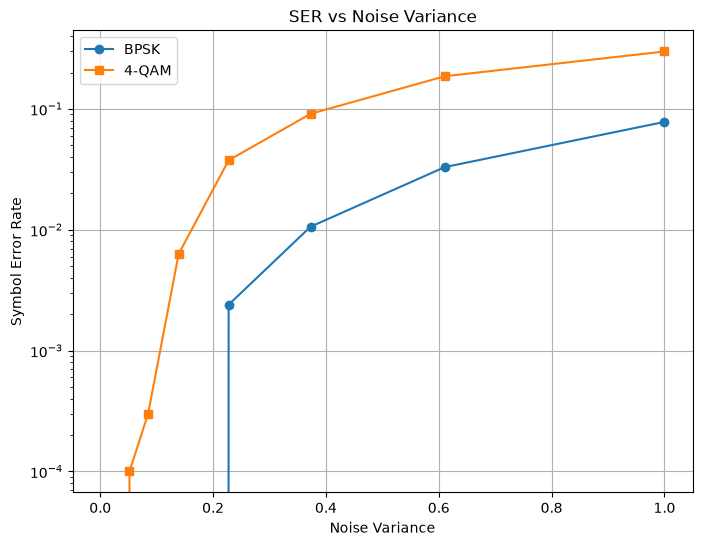

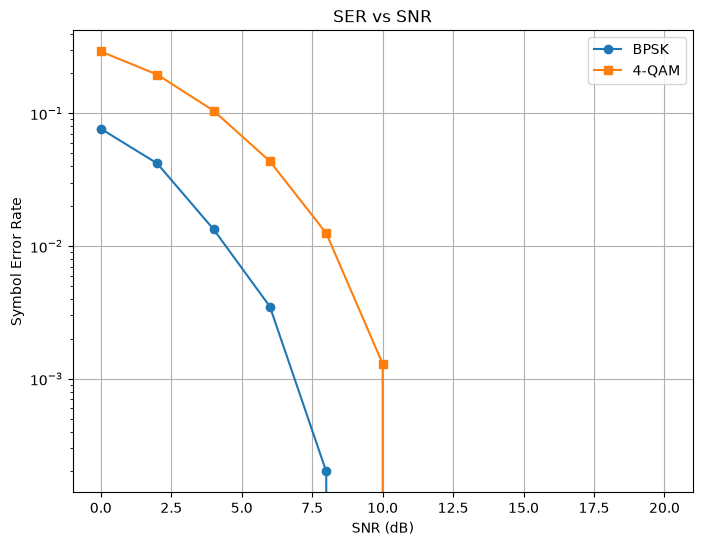

In [5]:
###################################################################
# TODO: Simulation, Noise Addition, and Decoding
###################################################################

# Write your Task 2 implementation here.

import numpy as np
import matplotlib.pyplot as plt


# ---------------------------------------------------------------
# Parameters
# ---------------------------------------------------------------

num_symbols = 10000
Es = 1.0


# ===============================================================
# BPSK
# ===============================================================

# Generate random BPSK symbols

bits_bpsk = np.random.randint(0, 2, num_symbols)

bpsk_symbols = 2 * bits_bpsk - 1


# ---------------------------------------------------------------
# BPSK constellation
# ---------------------------------------------------------------

bpsk_constellation = np.array([
    -1 + 0j,
    1 + 0j
])


# ---------------------------------------------------------------
# Add Gaussian noise
# ---------------------------------------------------------------

noise_variance_bpsk = 0.2

# Generate real and imaginary Gaussian noise components

noise_bpsk_real = np.sqrt(
    noise_variance_bpsk / 2
) * np.random.randn(num_symbols)

noise_bpsk_imag = np.sqrt(
    noise_variance_bpsk / 2
) * np.random.randn(num_symbols)

# Combine real and imaginary noise components

noise_bpsk = (
    noise_bpsk_real
    + 1j * noise_bpsk_imag
)

# Received BPSK signal

rx_bpsk = bpsk_symbols + noise_bpsk


# ---------------------------------------------------------------
# BPSK decoding using minimum distance
# ---------------------------------------------------------------

decoded_bpsk = np.zeros(
    num_symbols,
    dtype=complex
)

for i in range(num_symbols):

    distances = np.abs(
        rx_bpsk[i] - bpsk_constellation
    )

    decoded_bpsk[i] = bpsk_constellation[
        np.argmin(distances)
    ]


# ---------------------------------------------------------------
# BPSK SER
# ---------------------------------------------------------------

bpsk_errors = np.sum(
    decoded_bpsk != bpsk_symbols
)

bpsk_ser = bpsk_errors / num_symbols

print("BPSK Symbol Error Rate:", bpsk_ser)


# ---------------------------------------------------------------
# Plot noisy BPSK symbols
# ---------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(
    np.real(rx_bpsk),
    np.imag(rx_bpsk),
    s=5,
    alpha=0.4,
    label="Noisy received symbols"
)

plt.scatter(
    np.real(bpsk_constellation),
    np.imag(bpsk_constellation),
    marker="x",
    s=100,
    label="Ideal constellation"
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1,
    label="Decision boundary"
)

plt.xlabel("In-Phase (Real)")
plt.ylabel("Quadrature (Imaginary)")
plt.title("Noisy BPSK Constellation")
plt.legend()
plt.grid()
plt.axis("equal")
plt.show()


# ---------------------------------------------------------------
# Plot decoded BPSK symbols
# ---------------------------------------------------------------

plt.figure(figsize=(8, 6))

# Points decoded as -1

mask_minus = decoded_bpsk == -1

plt.scatter(
    np.real(rx_bpsk[mask_minus]),
    np.imag(rx_bpsk[mask_minus]),
    s=5,
    label="Decoded -1"
)


# Points decoded as +1

mask_plus = decoded_bpsk == 1

plt.scatter(
    np.real(rx_bpsk[mask_plus]),
    np.imag(rx_bpsk[mask_plus]),
    s=5,
    label="Decoded +1"
)


# Plot ideal constellation points

plt.scatter(
    np.real(bpsk_constellation),
    np.imag(bpsk_constellation),
    marker="x",
    s=100,
    label="Ideal constellation"
)


# Decision boundary

plt.axvline(
    0,
    linestyle="--",
    linewidth=1,
    label="Decision boundary"
)

plt.xlabel("In-Phase (Real)")
plt.ylabel("Quadrature (Imaginary)")
plt.title("Decoded BPSK Symbols")
plt.legend()
plt.grid()
plt.axis("equal")
plt.show()


# ===============================================================
# 4-QAM
# ===============================================================

# Generate 4-QAM symbols

qam_level = np.sqrt(Es / 2)

real_bits = np.random.randint(
    0,
    2,
    num_symbols
)

imag_bits = np.random.randint(
    0,
    2,
    num_symbols
)


real_part = 2 * real_bits - 1
imag_part = 2 * imag_bits - 1


qam_symbols = qam_level * (
    real_part + 1j * imag_part
)


# ---------------------------------------------------------------
# 4-QAM constellation
# ---------------------------------------------------------------

qam_constellation = np.array([
    qam_level + 1j * qam_level,
    -qam_level + 1j * qam_level,
    qam_level - 1j * qam_level,
    -qam_level - 1j * qam_level
])


# ---------------------------------------------------------------
# Add Complex Standard Circular Gaussian Noise
# ---------------------------------------------------------------

noise_variance_qam = 0.2

noise_real = np.sqrt(
    noise_variance_qam / 2
) * np.random.randn(num_symbols)

noise_imag = np.sqrt(
    noise_variance_qam / 2
) * np.random.randn(num_symbols)


noise_qam = noise_real + 1j * noise_imag

rx_qam = qam_symbols + noise_qam


# ---------------------------------------------------------------
# 4-QAM decoding using minimum geometric distance
# ---------------------------------------------------------------

decoded_qam = np.zeros(
    num_symbols,
    dtype=complex
)

for i in range(num_symbols):

    distances = np.abs(
        rx_qam[i] - qam_constellation
    )

    decoded_qam[i] = qam_constellation[
        np.argmin(distances)
    ]


# ---------------------------------------------------------------
# 4-QAM SER
# ---------------------------------------------------------------

qam_errors = np.sum(
    decoded_qam != qam_symbols
)

qam_ser = qam_errors / num_symbols

print("4-QAM Symbol Error Rate:", qam_ser)


# ---------------------------------------------------------------
# Plot noisy 4-QAM symbols
# ---------------------------------------------------------------

plt.figure(figsize=(7, 7))

plt.scatter(
    np.real(rx_qam),
    np.imag(rx_qam),
    s=5,
    alpha=0.4,
    label="Noisy received symbols"
)

plt.scatter(
    np.real(qam_constellation),
    np.imag(qam_constellation),
    marker="x",
    s=100,
    label="Ideal constellation"
)

plt.xlabel("In-Phase (Real)")
plt.ylabel("Quadrature (Imaginary)")
plt.title("Noisy 4-QAM Constellation")
plt.legend()
plt.grid()
plt.axis("equal")
plt.show()


# ---------------------------------------------------------------
# Plot decoded 4-QAM symbols
# ---------------------------------------------------------------

plt.figure(figsize=(7, 7))

for symbol in qam_constellation:

    mask = decoded_qam == symbol

    plt.scatter(
        np.real(rx_qam[mask]),
        np.imag(rx_qam[mask]),
        s=5,
        label=f"Decoded {symbol}"
    )


plt.scatter(
    np.real(qam_constellation),
    np.imag(qam_constellation),
    marker="x",
    s=100,
    label="Ideal constellation"
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("In-Phase (Real)")
plt.ylabel("Quadrature (Imaginary)")
plt.title("Decoded 4-QAM Symbols")
plt.legend()
plt.grid()
plt.axis("equal")
plt.show()


# ---------------------------------------------------------------
# SER vs Noise Variance
# ---------------------------------------------------------------

noise_variances = np.logspace(
    -3,
    0,
    15
)

ser_bpsk = []
ser_qam = []


for variance in noise_variances:

    # BPSK

    noise_real = np.sqrt(
        variance / 2
    ) * np.random.randn(num_symbols)

    noise_imag = np.sqrt(
        variance / 2
    ) * np.random.randn(num_symbols)

    noise = noise_real + 1j * noise_imag

    rx = bpsk_symbols + noise


    # BPSK nearest-neighbor decoding

    decoded = np.zeros(
        num_symbols,
        dtype=complex
    )

    for i in range(num_symbols):

        distances = np.abs(
            rx[i] - bpsk_constellation
        )

        decoded[i] = bpsk_constellation[
            np.argmin(distances)
        ]


    errors = np.sum(
        decoded != bpsk_symbols
    )

    ser_bpsk.append(
        errors / num_symbols
    )


    # 4-QAM

    noise_real = np.sqrt(
        variance / 2
    ) * np.random.randn(num_symbols)

    noise_imag = np.sqrt(
        variance / 2
    ) * np.random.randn(num_symbols)

    noise = noise_real + 1j * noise_imag

    rx = qam_symbols + noise

    decoded = np.zeros(
        num_symbols,
        dtype=complex
    )

    for i in range(num_symbols):

        distances = np.abs(
            rx[i] - qam_constellation
        )

        decoded[i] = qam_constellation[
            np.argmin(distances)
        ]

    errors = np.sum(
        decoded != qam_symbols
    )

    ser_qam.append(
        errors / num_symbols
    )


# ---------------------------------------------------------------
# Plot SER vs Noise Variance
# ---------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.semilogy(
    noise_variances,
    ser_bpsk,
    marker="o",
    label="BPSK"
)

plt.semilogy(
    noise_variances,
    ser_qam,
    marker="s",
    label="4-QAM"
)

plt.xlabel("Noise Variance")
plt.ylabel("Symbol Error Rate")
plt.title("SER vs Noise Variance")
plt.legend()
plt.grid()
plt.show()


# ---------------------------------------------------------------
# SER vs SNR
# ---------------------------------------------------------------

snr_db = np.arange(
    0,
    21,
    2
)

ser_bpsk_snr = []
ser_qam_snr = []


for snr in snr_db:

    variance = Es / (
        10 ** (snr / 10)
    )


    # BPSK

    noise_real = np.sqrt(
        variance / 2
    ) * np.random.randn(num_symbols)

    noise_imag = np.sqrt(
        variance / 2
    ) * np.random.randn(num_symbols)

    noise = noise_real + 1j * noise_imag

    rx = bpsk_symbols + noise


    # BPSK nearest-neighbor decoding

    decoded = np.zeros(
        num_symbols,
        dtype=complex
    )

    for i in range(num_symbols):

        distances = np.abs(
            rx[i] - bpsk_constellation
        )

        decoded[i] = bpsk_constellation[
            np.argmin(distances)
        ]


    errors = np.sum(
        decoded != bpsk_symbols
    )

    ser_bpsk_snr.append(
        errors / num_symbols
    )


    # 4-QAM

    noise_real = np.sqrt(
        variance / 2
    ) * np.random.randn(num_symbols)

    noise_imag = np.sqrt(
        variance / 2
    ) * np.random.randn(num_symbols)

    rx = qam_symbols + (
        noise_real + 1j * noise_imag
    )

    decoded = np.zeros(
        num_symbols,
        dtype=complex
    )

    for i in range(num_symbols):

        distances = np.abs(
            rx[i] - qam_constellation
        )

        decoded[i] = qam_constellation[
            np.argmin(distances)
        ]

    errors = np.sum(
        decoded != qam_symbols
    )

    ser_qam_snr.append(
        errors / num_symbols
    )


# ---------------------------------------------------------------
# Plot SER vs SNR
# ---------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.semilogy(
    snr_db,
    ser_bpsk_snr,
    marker="o",
    label="BPSK"
)

plt.semilogy(
    snr_db,
    ser_qam_snr,
    marker="s",
    label="4-QAM"
)

plt.xlabel("SNR (dB)")
plt.ylabel("Symbol Error Rate")
plt.title("SER vs SNR")
plt.legend()
plt.grid()
plt.show()


# --- VISUALIZATION & INSIGHT TIPS ---
# TIP: To verify your decoder works, plot your noisy 4-QAM symbols using a scatter plot.
#      Color-code the received points based on what your decoder *thinks* they are
#      (e.g., color points decoded as +1+1j red, -1+1j blue, etc.).
#      You should see clear decision boundaries form along the axes!
# TIP: Ensure you plot the final SER vs. Variance (or SNR) on a logarithmic y-axis
#      (plt.semilogy) to better visualize the steep drop-off in errors.

## Task: End-to-End BPSK over SDR

Now that you understand noise modeling and basic decision-making mathematically, try putting it all together on the hardware! In this bonus task, your goal is to implement a full BPSK transmission and reception pipeline over the air.

**The Flow:**
1. **Generate Symbols:** Create an array of random BPSK symbols (e.g., sequence of `+1`s and `-1`s).
2. **Transmit:** Scale them properly and send them through the `tx_sdr`.
3. **Receive:** Capture the raw samples via `rx_sdr`.
4. **Process:** Apply your coarse frequency correction. This is vital to stop the constellation from spinning in the complex plane so you can actually read the phase!
5. **Demodulate:** Extract the real part of the corrected signal and use the geometric intuition you developed in Task 2 to decode the received samples back into the original bits.

*(No code template is provided for this—use the modular pieces you've built in Labs 2 and 3 to construct the pipeline!)*

Connecting to TX Pluto...
Connecting to RX Pluto...
Both Plutos connected.

Random TX bits:
[1 0 0 1 1 1 0 0 0 0 0 0 1 0 1 1 0 0 0 1 1 0 0 1 1 0 0 1 0 1 1 0 0 1 1 0 1
 1 1 1 0 1 0 1 0 0 0 1 1 0 0 0 0 1 0 0 0 1 1 1 1 0 0 0 0 1 1 1 0 1 1 1 0 1
 0 1 0 1 1 1 0 0 0 0 1 1 0 1 1 0 0 1 1 0 1 0 0 1 1 1]

Complete TX frame:
[1 1 0 0 1 1 1 0 0 0 0 0 0 1 0 1 1 0 0 0 1 1 0 0 1 1 0 0 1 0 1 1 0 0 1 1 0
 1 1 1 1 0 1 0 1 0 0 0 1 1 0 0 0 0 1 0 0 0 1 1 1 1 0 0 0 0 1 1 1 0 1 1 1 0
 1 0 1 0 1 1 1 0 0 0 0 1 1 0 1 1 0 0 1 1 0 1 0 0 1 1 1]

BPSK symbols:
[ 1  1 -1 -1  1  1  1 -1 -1 -1 -1 -1 -1  1 -1  1  1 -1 -1 -1  1  1 -1 -1
  1  1 -1 -1  1 -1  1  1 -1 -1  1  1 -1  1  1  1  1 -1  1 -1  1 -1 -1 -1
  1  1 -1 -1 -1 -1  1 -1 -1 -1  1  1  1  1 -1 -1 -1 -1  1  1  1 -1  1  1
  1 -1  1 -1  1 -1  1  1  1 -1 -1 -1 -1  1  1 -1  1  1 -1 -1  1  1 -1  1
 -1 -1  1  1  1]

Total TX samples: 20200

RX started...

Starting transmission...
Transmission completed.
RX capture completed.

Received samples: 100000

Estimated RX DC

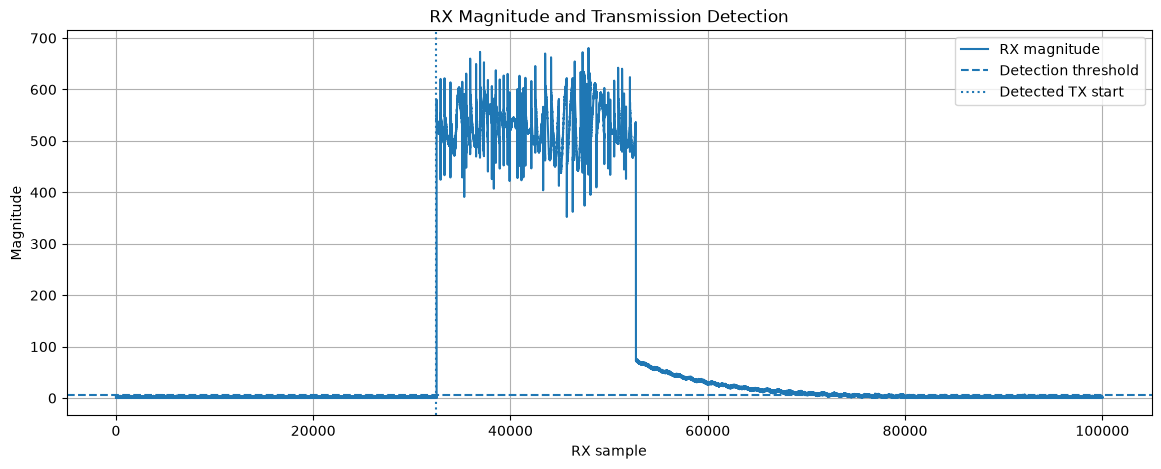

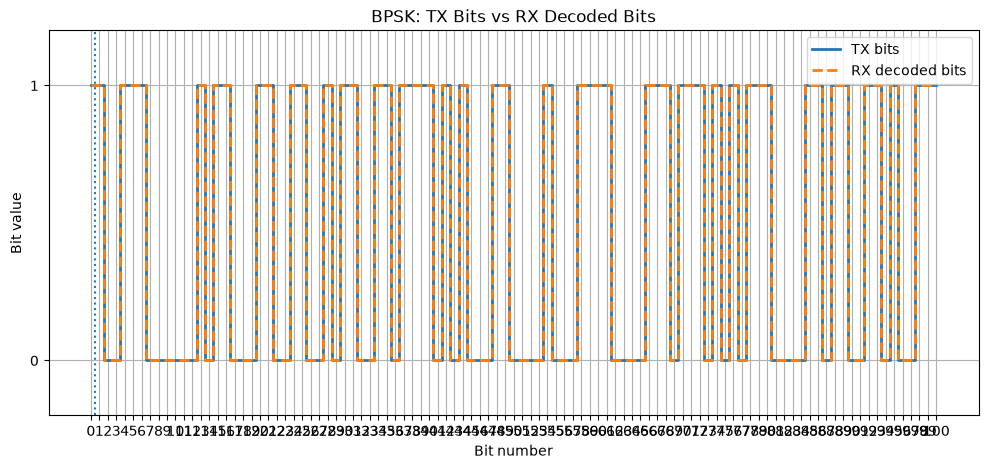

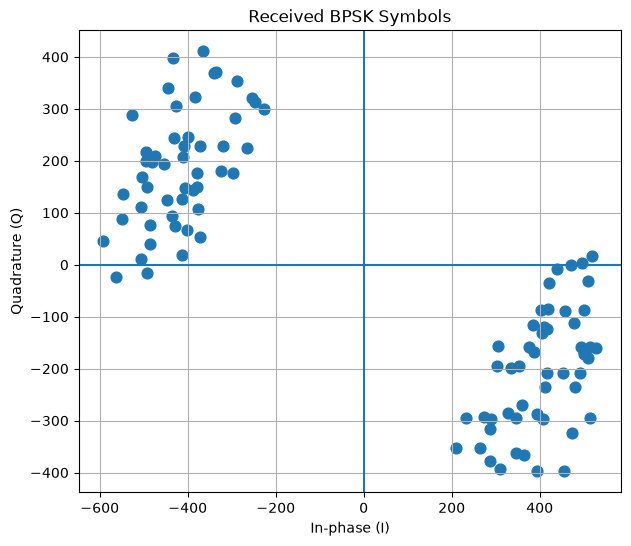


BPSK end-to-end test completed.


In [103]:
import adi
import numpy as np
import matplotlib.pyplot as plt
import threading
import time


# ============================================================
# 1. PARAMETERS
# ============================================================

# ---------------- Pluto IP addresses ----------------

TX_IP = "192.168.3.1"
RX_IP = "192.168.2.1"


# ---------------- SDR parameters ----------------

FS = int(2.0e6)             # Sample rate = 2 MHz
FC = int(823e6)             # Carrier frequency = 823 MHz

TX_SCALE = 2**14


# ---------------- BPSK parameters ----------------

NUM_BITS = 100

# Each bit is represented by 100 samples
SAMPLES_PER_SYMBOL = 200

# Known START bit
START_BIT = 1


# ---------------- RX parameters ----------------

# RX captures more samples than TX sends.
#
# TX:
#   11 bits x 100 samples = 1100 samples
#
# RX:
#   100000 samples
#
# At 2 MHz:
#
#   100000 / 2e6 = 50 ms

RX_BUFFER_SIZE = 100000


# ---------------- Timing ----------------

# RX will capture this much noise before TX starts.
#
# 10 ms at 2 MHz:
#
#   0.010 x 2e6 = 20000 samples

RX_NOISE_TIME = 0.010


# ---------------- Transmission detection ----------------

# Number of consecutive samples above threshold
# required to declare transmission started.

MIN_CONSECUTIVE_SAMPLES = 40

# Noise threshold:
#
# threshold = noise_mean + 4 * noise_std

THRESHOLD_STD_MULTIPLIER = 4


# ============================================================
# 2. CONNECT TO TX PLUTO
# ============================================================

print("Connecting to TX Pluto...")

tx_sdr = adi.Pluto(
    f"ip:{TX_IP}"
)


# ============================================================
# 3. CONNECT TO RX PLUTO
# ============================================================

print("Connecting to RX Pluto...")

rx_sdr = adi.Pluto(
    f"ip:{RX_IP}"
)


print("Both Plutos connected.")


# ============================================================
# 4. CONFIGURE TX PLUTO
# ============================================================

tx_sdr.sample_rate = FS

tx_sdr.tx_lo = FC

tx_sdr.tx_rf_bandwidth = FS

tx_sdr.tx_hardwaregain_chan0 = -10


# Send frame only once.

tx_sdr.tx_cyclic_buffer = False


# ============================================================
# 5. CONFIGURE RX PLUTO
# ============================================================

rx_sdr.sample_rate = FS

rx_sdr.rx_lo = FC

rx_sdr.rx_rf_bandwidth = FS

rx_sdr.gain_control_mode_chan0 = "manual"

rx_sdr.rx_hardwaregain_chan0 = 30

rx_sdr.rx_buffer_size = RX_BUFFER_SIZE


# ============================================================
# 6. GENERATE RANDOM DATA
# ============================================================

tx_bits = np.random.randint(
    0,
    2,
    NUM_BITS
)


print()
print("Random TX bits:")
print(tx_bits)


# ============================================================
# 7. CREATE FRAME
# ============================================================

# Frame:
#
# START | 10 RANDOM DATA BITS
#
#    1  |  1 0 1 0 1 1 0 0 1 0

frame_bits = np.concatenate(
    (
        np.array([START_BIT]),
        tx_bits
    )
)


print()
print("Complete TX frame:")
print(frame_bits)


# ============================================================
# 8. BPSK MODULATION
# ============================================================

# BPSK:
#
#   1 -> +1
#   0 -> -1

bpsk_symbols = (
    2 * frame_bits - 1
)


print()
print("BPSK symbols:")
print(bpsk_symbols)


# ============================================================
# 9. CONVERT EACH BIT INTO 100 SAMPLES
# ============================================================

# Example:
#
# bit 1:
#
# +1 +1 +1 +1 ... 100 samples
#
# bit 0:
#
# -1 -1 -1 -1 ... 100 samples

tx_samples = np.repeat(
    bpsk_symbols,
    SAMPLES_PER_SYMBOL
)


# Convert to complex IQ.

tx_samples = tx_samples.astype(
    np.complex64
)


# Scale signal.

tx_samples = (
    tx_samples *
    TX_SCALE
)


print()
print(
    "Total TX samples:",
    len(tx_samples)
)


# ============================================================
# 10. START RX FIRST
# ============================================================

rx_result = []


def receive_samples():

    print()
    print("RX started...")

    samples = rx_sdr.rx()

    rx_result.append(
        samples
    )

    print("RX capture completed.")


rx_thread = threading.Thread(
    target=receive_samples
)


rx_thread.start()


# Give RX enough time to begin capturing.
#
# IMPORTANT:
# Do not wait longer than the RX capture duration.
#
# RX capture duration:
#
# 100000 / 2e6 = 50 ms

time.sleep(
    RX_NOISE_TIME
)


# ============================================================
# 11. TRANSMIT ONCE
# ============================================================

print()
print("Starting transmission...")

tx_sdr.tx(
    tx_samples
)

print("Transmission completed.")


# Wait for RX capture to finish.

rx_thread.join()


# Get received samples.

rx_samples = rx_result[0]


print()
print(
    "Received samples:",
    len(rx_samples)
)


# ============================================================
# 12. ESTIMATE DC FROM NOISE-ONLY REGION
# ============================================================

# The first 20,000 samples are supposed to contain
# no TX signal.
#
# We use them to estimate the RX DC component.

NOISE_SAMPLE_COUNT = int(
    FS * RX_NOISE_TIME
)


noise_only_samples = (
    rx_samples[
        :NOISE_SAMPLE_COUNT
    ]
)


dc_estimate = np.mean(
    noise_only_samples
)


print()
print(
    "Estimated RX DC:",
    dc_estimate
)


# Remove ONLY the estimated DC.
#
# We do NOT use the average of the complete
# RX buffer because it contains the TX signal.

rx_dc_removed = (
    rx_samples -
    dc_estimate
)


# ============================================================
# 13. CALCULATE RX MAGNITUDE
# ============================================================

rx_magnitude = np.abs(
    rx_dc_removed
)


# ============================================================
# 14. NOISE STATISTICS
# ============================================================

noise_magnitude = (
    rx_magnitude[
        :NOISE_SAMPLE_COUNT
    ]
)


noise_mean = np.mean(
    noise_magnitude
)


noise_std = np.std(
    noise_magnitude
)


noise_max = np.max(
    noise_magnitude
)


print()
print("==========================================")
print("         RX MAGNITUDE STATISTICS")
print("==========================================")

print(
    "Noise mean :",
    noise_mean
)

print(
    "Noise std  :",
    noise_std
)

print(
    "Noise max  :",
    noise_max
)

print(
    "RX max     :",
    np.max(rx_magnitude)
)


# ============================================================
# 15. CALCULATE DETECTION THRESHOLD
# ============================================================

# Use mean + 3 standard deviations.
#
# This is more adaptive than:
#
#     threshold = noise_mean * 5

threshold = (
    noise_mean +
    THRESHOLD_STD_MULTIPLIER *
    noise_std
)


print(
    "Detection threshold:",
    threshold
)


# ============================================================
# 16. DETECT TRANSMISSION START
# ============================================================

# Transmission start is detected from magnitude.
#
# Before TX:
#
#   magnitude = noise
#
# During TX:
#
#   magnitude = much larger
#
# We require multiple consecutive samples
# above threshold.


above_threshold = (
    rx_magnitude > threshold
)


transmission_start = None

consecutive_count = 0


for i in range(
    NOISE_SAMPLE_COUNT,
    len(above_threshold)
):

    if above_threshold[i]:

        consecutive_count += 1

    else:

        consecutive_count = 0


    if (
        consecutive_count >=
        MIN_CONSECUTIVE_SAMPLES
    ):

        transmission_start = (
            i -
            MIN_CONSECUTIVE_SAMPLES +
            1
        )

        break


# Check whether transmission was found.

if transmission_start is None:

    print()
    print("==========================================")
    print("     TRANSMISSION NOT DETECTED")
    print("==========================================")

    print(
        "Noise mean:",
        noise_mean
    )

    print(
        "Noise std:",
        noise_std
    )

    print(
        "Threshold:",
        threshold
    )

    print(
        "Maximum RX magnitude:",
        np.max(rx_magnitude)
    )

    raise RuntimeError(
        "Transmission was not detected."
    )


print()
print(
    "Transmission detected at sample:",
    transmission_start
)


# ============================================================
# 17. EXPECTED FRAME SIZE
# ============================================================

# One START bit
# +
# NUM_BITS data bits

TOTAL_FRAME_BITS = (
    1 + NUM_BITS
)


TOTAL_FRAME_SAMPLES = (
    TOTAL_FRAME_BITS *
    SAMPLES_PER_SYMBOL
)


print(
    "Expected frame samples:",
    TOTAL_FRAME_SAMPLES
)


# ============================================================
# 18. CHECK FRAME FITS IN RX BUFFER
# ============================================================

frame_end = (
    transmission_start +
    TOTAL_FRAME_SAMPLES
)


if frame_end > len(rx_dc_removed):

    raise RuntimeError(
        "Complete frame is outside RX buffer."
    )


# ============================================================
# 19. SMALL LOCAL START ALIGNMENT
# ============================================================

# The threshold detector gives us a good estimate
# of the transmission start.
#
# The RF signal can take a few samples to rise.
#
# So we search a SMALL area around that point.
#
# We do NOT search the whole RX buffer.
#
# The best symbol boundary should produce the
# most coherent 100-sample signal.


ALIGN_SEARCH = 20


search_start = max(
    NOISE_SAMPLE_COUNT,
    transmission_start -
    ALIGN_SEARCH
)


search_end = min(
    len(rx_dc_removed) -
    SAMPLES_PER_SYMBOL,
    transmission_start +
    ALIGN_SEARCH
)


best_start = transmission_start

best_coherence = -1


for position in range(
    search_start,
    search_end + 1
):

    candidate = (
        rx_dc_removed[
            position:
            position +
            SAMPLES_PER_SYMBOL
        ]
    )


    # Coherence:
    #
    # |sum(samples)| / sum(|samples|)
    #
    # If the samples belong to one BPSK symbol,
    # they should point approximately in the same
    # direction, giving high coherence.

    numerator = np.abs(
        np.sum(candidate)
    )


    denominator = (
        np.sum(np.abs(candidate))
        + 1e-12
    )


    coherence = (
        numerator /
        denominator
    )


    if coherence > best_coherence:

        best_coherence = coherence

        best_start = position


transmission_start = best_start


print(
    "Aligned transmission start:",
    transmission_start
)


print(
    "START coherence:",
    best_coherence
)


# ============================================================
# 20. EXTRACT ONLY THE 1100 TRANSMITTED SAMPLES
# ============================================================

frame_end = (
    transmission_start +
    TOTAL_FRAME_SAMPLES
)


rx_frame = (
    rx_dc_removed[
        transmission_start:
        frame_end
    ]
)


print()
print(
    "Actual RX frame samples:",
    len(rx_frame)
)


# ============================================================
# 21. ESTIMATE FREQUENCY OFFSET FROM START BIT
# ============================================================

# IMPORTANT:
#
# We use ONLY the known START bit.
#
# START = 1
#
# BPSK:
#
# START = +1
#
# Therefore the phase should be constant.
#
# Any phase change with sample number is
# caused mainly by frequency offset.


start_samples = (
    rx_frame[
        0:
        SAMPLES_PER_SYMBOL
    ]
)


# Calculate consecutive-sample phase difference.

start_phase_difference = (
    start_samples[1:] *
    np.conj(
        start_samples[:-1]
    )
)


# Average the phase difference.

mean_start_phase_difference = np.mean(
    start_phase_difference
)


# Angle gives phase change per sample.

estimated_phase_per_sample = np.angle(
    mean_start_phase_difference
)


print()
print(
    "Estimated phase change/sample:",
    estimated_phase_per_sample
)


# ============================================================
# 22. FREQUENCY CORRECTION
# ============================================================

frame_sample_numbers = np.arange(
    TOTAL_FRAME_SAMPLES
)


frequency_correction = np.exp(
    -1j *
    estimated_phase_per_sample *
    frame_sample_numbers
)


rx_frequency_corrected = (
    rx_frame *
    frequency_correction
)


# ============================================================
# 23. ESTIMATE INITIAL PHASE
# ============================================================

# Get the START samples after frequency correction.

corrected_start = (
    rx_frequency_corrected[
        0:
        SAMPLES_PER_SYMBOL
    ]
)


# START = 1 -> ideal BPSK point = +1.
#
# Therefore the angle of the mean tells us
# the remaining initial phase offset.

start_mean = np.mean(
    corrected_start
)


estimated_initial_phase = np.angle(
    start_mean
)


print(
    "Estimated initial phase:",
    estimated_initial_phase
)


# ============================================================
# 24. PHASE CORRECTION
# ============================================================

phase_correction = np.exp(
    -1j *
    estimated_initial_phase
)


rx_corrected = (
    rx_frequency_corrected *
    phase_correction
)


# ============================================================
# 25. DECODE 11 BITS
# ============================================================

# Frame:
#
# Bit 0  = START
# Bit 1  = DATA 1
# Bit 2  = DATA 2
# ...
# Bit 10 = DATA 10
#
# Every bit = 100 samples.


rx_frame_bits = []

ones_count = []

zeros_count = []


for bit_number in range(
    TOTAL_FRAME_BITS
):

    # --------------------------------------------------------
    # Get the 100 samples of this bit
    # --------------------------------------------------------

    start = (
        bit_number *
        SAMPLES_PER_SYMBOL
    )


    end = (
        start +
        SAMPLES_PER_SYMBOL
    )


    bit_samples = (
        rx_corrected[
            start:end
        ]
    )


    # --------------------------------------------------------
    # Decode every sample
    # --------------------------------------------------------

    sample_decisions = (
        np.real(bit_samples) >= 0
    ).astype(int)


    # --------------------------------------------------------
    # Count 1s
    # --------------------------------------------------------

    number_of_ones = np.sum(
        sample_decisions == 1
    )


    # --------------------------------------------------------
    # Count 0s
    # --------------------------------------------------------

    number_of_zeros = np.sum(
        sample_decisions == 0
    )


    ones_count.append(
        number_of_ones
    )


    zeros_count.append(
        number_of_zeros
    )


    # --------------------------------------------------------
    # Majority decision
    # --------------------------------------------------------

    if number_of_ones >= number_of_zeros:

        decoded_bit = 1

    else:

        decoded_bit = 0


    rx_frame_bits.append(
        decoded_bit
    )


rx_frame_bits = np.array(
    rx_frame_bits,
    dtype=int
)


# ============================================================
# 26. PRINT MAJORITY-VOTING RESULTS
# ============================================================

print()
print("==========================================")
print("            RX BIT DECODING")
print("==========================================")

print(
    "Bit     1-count     0-count     RX"
)

print(
    "------------------------------------------"
)


for i in range(
    TOTAL_FRAME_BITS
):

    print(
        f"{i:2d}      "
        f"{ones_count[i]:3d}         "
        f"{zeros_count[i]:3d}         "
        f"{rx_frame_bits[i]}"
    )


# ============================================================
# 27. CHECK START BIT
# ============================================================

print()
print(
    "TX START bit:",
    START_BIT
)

print(
    "RX START bit:",
    rx_frame_bits[0]
)


# ============================================================
# 28. REMOVE START BIT
# ============================================================

# START is only for synchronization.
#
# It is NOT included in BER.

rx_data_bits = (
    rx_frame_bits[1:]
)


# ============================================================
# 29. COMPARE TX AND RX DATA
# ============================================================

compare_count = min(
    len(tx_bits),
    len(rx_data_bits)
)


tx_compare = (
    tx_bits[
        :compare_count
    ]
)


rx_compare = (
    rx_data_bits[
        :compare_count
    ]
)


# ============================================================
# 30. CALCULATE BIT ERRORS
# ============================================================

bit_errors = np.sum(
    tx_compare != rx_compare
)


# ============================================================
# 31. CALCULATE BER
# ============================================================

if compare_count > 0:

    ber = (
        bit_errors /
        compare_count
    )

else:

    ber = np.nan


# ============================================================
# 32. PRINT FINAL RESULT
# ============================================================

print()
print("==========================================")
print("              BPSK RESULTS")
print("==========================================")

print()

print(
    "TX data bits:"
)

print(
    tx_compare
)


print()

print(
    "RX decoded bits:"
)

print(
    rx_compare
)


print()

print(
    "Total bits compared:",
    compare_count
)


print(
    "Bit errors:",
    bit_errors
)


print(
    "BER:",
    ber
)


print()
print("==========================================")


# ============================================================
# 33. PLOT RX MAGNITUDE
# ============================================================

plt.figure(
    figsize=(14, 5)
)


plt.plot(
    rx_magnitude,
    label="RX magnitude"
)


plt.axhline(
    threshold,
    linestyle="--",
    label="Detection threshold"
)


plt.axvline(
    transmission_start,
    linestyle=":",
    label="Detected TX start"
)


plt.xlabel(
    "RX sample"
)


plt.ylabel(
    "Magnitude"
)


plt.title(
    "RX Magnitude and Transmission Detection"
)


plt.grid(
    True
)


plt.legend()


plt.show()


# ============================================================
# 34. PLOT TX VS RX BITS
# ============================================================

plot_count = min(
    len(frame_bits),
    len(rx_frame_bits)
)


bit_numbers = np.arange(
    plot_count
)


plt.figure(
    figsize=(12, 5)
)


# TX bits

plt.step(
    bit_numbers,
    frame_bits[:plot_count],
    where="mid",
    linewidth=2,
    label="TX bits"
)


# RX bits

plt.step(
    bit_numbers,
    rx_frame_bits[:plot_count],
    where="mid",
    linestyle="--",
    linewidth=2,
    label="RX decoded bits"
)


# Separate START from DATA

plt.axvline(
    0.5,
    linestyle=":"
)


plt.xticks(
    bit_numbers
)


plt.yticks(
    [0, 1]
)


plt.xlabel(
    "Bit number"
)


plt.ylabel(
    "Bit value"
)


plt.title(
    "BPSK: TX Bits vs RX Decoded Bits"
)


plt.ylim(
    -0.2,
    1.2
)


plt.grid(
    True
)


plt.legend()


plt.show()


# ============================================================
# 35. PLOT RECEIVED BPSK SYMBOLS
# ============================================================

rx_symbols = []


for bit_number in range(
    TOTAL_FRAME_BITS
):

    start = (
        bit_number *
        SAMPLES_PER_SYMBOL
    )


    end = (
        start +
        SAMPLES_PER_SYMBOL
    )


    symbol_samples = (
        rx_corrected[
            start:end
        ]
    )


    symbol_average = np.mean(
        symbol_samples
    )


    rx_symbols.append(
        symbol_average
    )


rx_symbols = np.array(
    rx_symbols
)


plt.figure(
    figsize=(7, 6)
)


plt.scatter(
    np.real(rx_symbols),
    np.imag(rx_symbols),
    s=60
)


plt.axhline(0)

plt.axvline(0)


plt.xlabel(
    "In-phase (I)"
)


plt.ylabel(
    "Quadrature (Q)"
)


plt.title(
    "Received BPSK Symbols"
)


plt.grid(
    True
)


plt.show()


# ============================================================
# 36. CLEANUP
# ============================================================

try:

    tx_sdr.tx_destroy_buffer()

except:

    pass


print()
print("BPSK end-to-end test completed.")

# BPSK Transmission Idea Lab-3

## 1. BPSK Transmission

Use **BPSK** for transmission.

## 2. START Bit

Use **1 as the START bit**.

## 3. Random Data

Generate **10 random data bits** after the START bit.

## 4. BPSK Mapping

Map the bits using BPSK:

```text
1 -> +1
0 -> -1
```

## 5. Samples per Bit

Transmit each bit using **100 samples**.

## 6. Detect Transmission Start

At the receiver, initially there is only noise, so the received magnitude is low.

When transmission starts, the received magnitude becomes higher than the noise level.

Detect this point as the **start of transmission**.

## 7. Divide Received Samples

From the detected start point:

```text
First 100 samples   -> START bit
Next 100 samples    -> Data bit 1
Next 100 samples    -> Data bit 2
Next 100 samples    -> Data bit 3
...
Next 100 samples    -> Data bit 10
```

## 8. Decode Each Sample

For each 100-sample bit, decode every sample individually:

```text
Positive real part -> 1
Negative real part -> 0
```

## 9. Majority Voting

Count the number of `1`s and `0`s among the 100 samples.

Select the bit with the **higher count** as the decoded bit.

```text
Number of 1s > Number of 0s -> Decoded bit = 1

Number of 0s > Number of 1s -> Decoded bit = 0
```

## 10. Frequency and Phase Correction

Use the known **START bit** to estimate the **frequency offset** and **initial phase**.

Then apply frequency and phase correction before final bit decoding.

## 11. Compare TX and RX Bits

Compare the **10 transmitted random bits** with the **10 received decoded bits**.

```text
TX bits -> Original random bits

RX bits -> Decoded random bits
```

## 12. Calculate BER

Calculate the Bit Error Rate:

```text
BER = Number of bit errors / Total number of transmitted data bits
```

## 13. Plot TX and RX Bits

Plot the **transmitted TX bits** and **received RX decoded bits** to visually compare them.


## Final Lab Questions

Please answer the following questions based on your observations in this lab:

1. **Noise Distributions:** What is the fundamental difference between standard real Gaussian noise (GN) and complex standard circular Gaussian noise (CSCGN)? How did you visually verify this difference in Task 1?
2. **Hardware Impact:** How did the variance of your isolated noise in Task 1 change as you adjusted the SDR's receiver gain (`rx_hardwaregain_chan0`)? Why does this happen?
3. **Decoding Logic:** In Task 2, why is the minimum geometric distance (Maximum Likelihood) rule the most logical choice for decoding symbols in the presence of Additive White Gaussian Noise? What assumption are we making about the noise cloud for this rule to be optimal?
4. **Simulation vs. Reality:** What unique challenges would you face when moving from the purely mathematical Python simulation in Task 2 to the physical hardware in the Bonus Task? Name at least one impairment the real hardware introduces that the simple $y = s + w$ equation does not account for.

## Answers

1. The main difference b/w Standard real Gaussian Noise and complex standard circular gaussian nois is that SRGN as only real component whereas CSCGN as two independent GN components in in-phase and quadrature.

    In task 1, I plotted GN and CSCGN in GN histrogram is similar to Gaussian where in CSCGN the noise is circular around origin and it histrogram in I and Q are smilar to Gauusian distribution.

2. As the receiver gain was increased the variance of the noise also increased it mean noise power/energy increased this is because small noise to amplied by reciver gain so variance increases.

3. The decoding logic used used is here mid point is zero so above zero is 1 whereas below zero is 0.We use assumption that noise cloud is arounf each transmitted symbol is approx circular and symmetric by that we make minimum distance rule

4. In simulation we only considered additive noise wheeas in real life we also have atteation , Multiple path interaction and frequency offset due to clock frequency error.With the real hardware we will face all above problems mean while we only considered addtive noise.